cargamos los datos y entrenamos el modelo

In [2]:
!pip install tensorflow

  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.4.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/375.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/375.7 MB 2.4 MB/s eta 0:02:36
   ---------------------------------------- 1.6/375.7 MB 3.1 MB/s eta 0:02:01
   ---------------------------------------- 3.4/375.7 MB 4.8 MB/s eta 0:01:18
    --------------------------------------- 6.8/375.7 MB 7.5 MB/s eta 0:00:50
   - -------------------------------------- 10.7/375.7 MB 9.6 MB/s eta 0:00:39
   - -------------------------------------- 18.1/375.7 MB 13.6 MB/s eta 0:00:27
  

  You can safely remove it manually.
  You can safely remove it manually.



Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.3129 - loss: 1.9215 - val_accuracy: 0.7425 - val_loss: 0.9399
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7689 - loss: 0.7844 - val_accuracy: 0.8695 - val_loss: 0.4550
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8717 - loss: 0.4200 - val_accuracy: 0.8937 - val_loss: 0.3419
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9078 - loss: 0.3025 - val_accuracy: 0.9215 - val_loss: 0.2620
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9195 - loss: 0.2570 - val_accuracy: 0.9331 - val_loss: 0.2232
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       980
           1       0.98      0.97      0.98      1135
           2       0.94      0.95      0.94      1032
           3       0.92      0.96      0.94      1010
           4       0.97      0.86      0.91   

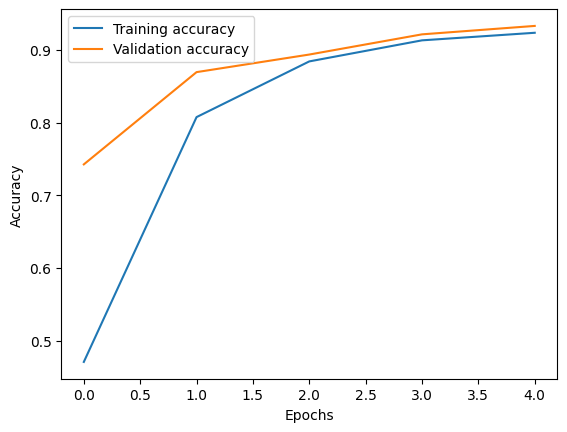

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from TheModel import build

#split
i = 3
# Cargar datos
local_data = np.load(f"local_data_splits\\local_data_split_{i}.npz")
x_local, y_local = local_data["x"], local_data["y"]

datos_test = np.load("local_data_splits\\datos_test_mnist.npz")
x_test, y_test = datos_test["x_test"], datos_test["y_test"]

# Construir y compilar el modelo
local_model = build.build_it()

# Entrenar y validar
history = local_model.fit(x_local, y_local, epochs=5, validation_data=(x_test, y_test))

# Evaluar y reportar resultados
y_pred = local_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes))

# Gráfica de precisión
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Guardar modelo entrenado
local_model.save(f"modelos/lmodel_{i}.keras")
